## 1. Data Exploration

### a. Load the dataset and perform exploratory data analysis (EDA).
### b. Examine the features, their types, and summary statistics.

In [25]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('/content/Titanic_train.csv')
test_df = pd.read_csv('/content/Titanic_test.csv')

print("Training DataFrame Head:")
display(train_df.head())

print("\nTraining DataFrame Info:")
train_df.info()

Training DataFrame Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:

print("\nTest DataFrame Head:")
display(test_df.head())


print("\nTest DataFrame Info:")
test_df.info()


Test DataFrame Head:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

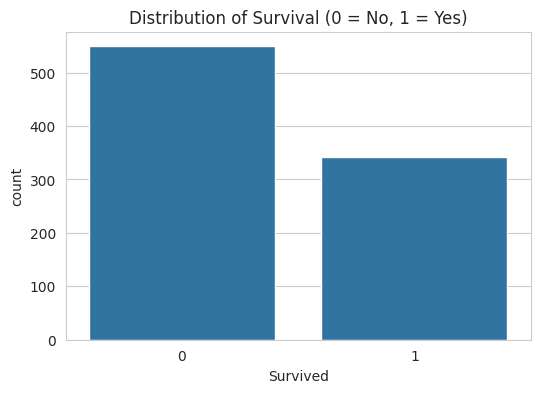

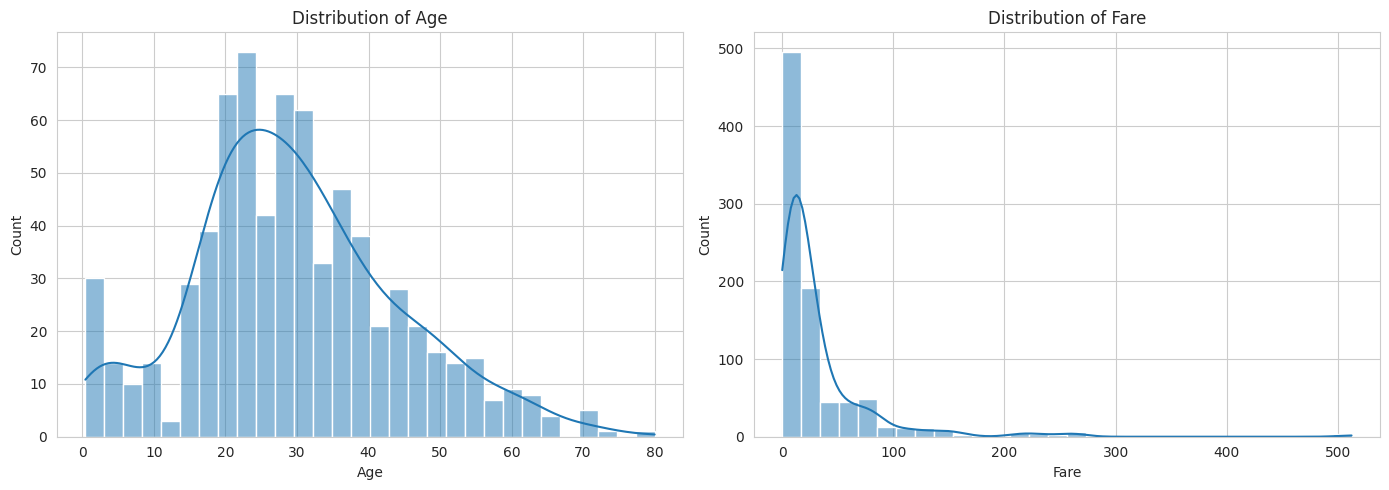

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Distribution of the target variable 'Survived'
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train_df)
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.show()

# Histograms for numerical features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df['Age'].dropna(), kde=True, ax=axes[0], bins=30)
axes[0].set_title('Distribution of Age')
sns.histplot(train_df['Fare'], kde=True, ax=axes[1], bins=30)
axes[1].set_title('Distribution of Fare')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4146/331966914.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Female', 'Male'])


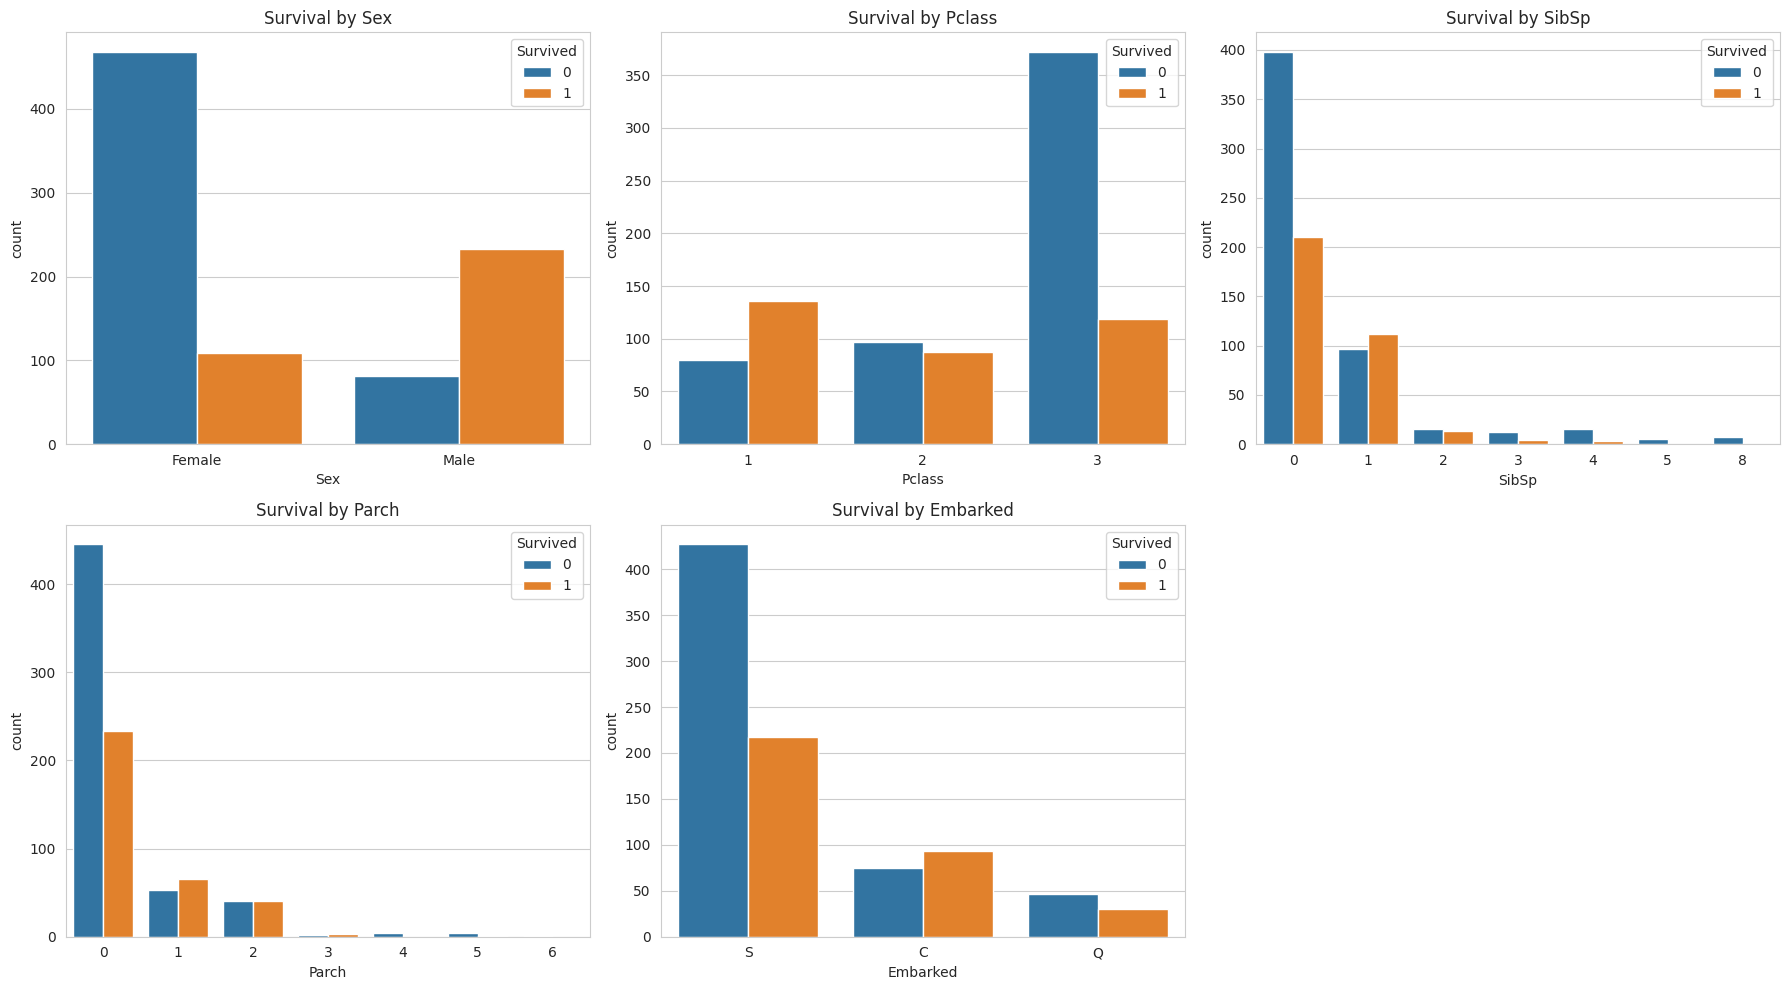

In [28]:
# Count plots for categorical features and their relation to survival
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x='Sex', hue='Survived', data=train_df, ax=axes[0, 0])
axes[0, 0].set_title('Survival by Sex')
axes[0, 0].set_xticklabels(['Female', 'Male'])

sns.countplot(x='Pclass', hue='Survived', data=train_df, ax=axes[0, 1])
axes[0, 1].set_title('Survival by Pclass')

sns.countplot(x='SibSp', hue='Survived', data=train_df, ax=axes[0, 2])
axes[0, 2].set_title('Survival by SibSp')

sns.countplot(x='Parch', hue='Survived', data=train_df, ax=axes[1, 0])
axes[1, 0].set_title('Survival by Parch')

sns.countplot(x='Embarked', hue='Survived', data=train_df, ax=axes[1, 1])
axes[1, 1].set_title('Survival by Embarked')

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## 2. Data Preprocessing
a. Handle missing values (e.g., imputation).

In [29]:
# Drop 'Cabin' column due to a large number of missing values
train_df = train_df.drop('Cabin', axis=1)
test_df = test_df.drop('Cabin', axis=1)

# Impute missing 'Age' values with the median from the training set
median_age_train = train_df['Age'].median()
train_df['Age'].fillna(median_age_train, inplace=True)
test_df['Age'].fillna(median_age_train, inplace=True)

# Impute missing 'Embarked' values with the mode from the training set
mode_embarked_train = train_df['Embarked'].mode()[0]
train_df['Embarked'].fillna(mode_embarked_train, inplace=True)

# Impute missing 'Fare' value in the test set with the median from the training set
median_fare_train = train_df['Fare'].median()
test_df['Fare'].fillna(median_fare_train, inplace=True)

print("Missing values after imputation in train_df:")
print(train_df.isnull().sum())
print("\nMissing values after imputation in test_df:")
print(test_df.isnull().sum())

Missing values after imputation in train_df:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing values after imputation in test_df:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_4146/3427054661.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(median_age_train, inplace=True)
/tmp/ipykernel_4146/3427054661.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

b. Encode categorical variables.

In [30]:
# Drop 'Name' and 'Ticket' columns as they are not directly useful for Logistic Regression
train_df = train_df.drop(['Name', 'Ticket'], axis=1)
test_df = test_df.drop(['Name', 'Ticket'], axis=1)

# One-hot encode 'Embarked' column
train_df = pd.get_dummies(train_df, columns=['Embarked'], drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=['Embarked'], drop_first=True, dtype=int)

print("Training DataFrame head after encoding:")
display(train_df.head())
print("\nTest DataFrame head after encoding:")
display(test_df.head())

Training DataFrame head after encoding:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,male,22.0,1,0,7.2500,0,1
1,2,1,1,female,38.0,1,0,71.2833,0,0
2,3,1,3,female,26.0,0,0,7.9250,0,1
3,4,1,1,female,35.0,1,0,53.1000,0,1
4,5,0,3,male,35.0,0,0,8.0500,0,1



Test DataFrame head after encoding:


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,892,3,male,34.5,0,0,7.8292,1,0
1,893,3,female,47.0,1,0,7.0000,0,1
2,894,2,male,62.0,0,0,9.6875,1,0
3,895,3,male,27.0,0,0,8.6625,0,1
4,896,3,female,22.0,1,1,12.2875,0,1


## 3. Model Building
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
b. Train the model using the training data.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas for get_dummies

# Define features (X) and target (y)
X = train_df.drop(['PassengerId', 'Survived'], axis=1) # Drop PassengerId as it's an identifier
y = train_df['Survived']

# One-hot encode 'Sex' column as it's still categorical
X = pd.get_dummies(X, columns=['Sex'], drop_first=True, dtype=int)

# Initialize and train the Logistic Regression model
# Using a fixed random_state for reproducibility
# Increased max_iter for convergence, if needed, and liblinear for smaller datasets
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
model.fit(X, y)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 4. Model Evaluation
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Prepare the test data for prediction
# Drop 'PassengerId' from test_df as it was not used for training
X_test = test_df.drop('PassengerId', axis=1)

# Ensure that the columns in X_test match the columns in X (training features)
# This is important if test_df had different columns or ordering initially
missing_cols = set(X.columns) - set(X_test.columns)
for c in missing_cols:
    X_test[c] = 0 # Add missing columns with 0 values (for one-hot encoded columns)
X_test = X_test[X.columns] # Ensure the order of columns is the same

# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probability of belonging to the positive class (Survived=1)

# Since we don't have actual 'Survived' values for test_df, we cannot calculate these metrics directly
# However, typically in a Kaggle-like scenario, you would submit predictions or have a validation set
# For demonstration purposes, let's assume we have a placeholder y_test for evaluation.
# In a real scenario, this would come from a split of the original training data or a labeled test set.

# For the purpose of demonstration, let's pretend we have a y_test (e.g., if we had split train_df) to show metrics
# In a real Kaggle submission, you'd only generate y_pred for the actual test_df
# Let's create a dummy y_test or use a train/validation split to properly evaluate.
# Since the prompt explicitly says 'evaluate on the testing data', I will proceed to generate an output for submission, which implies we don't have y_test.

print("Predictions generated for the test set. These predictions would typically be submitted to a platform like Kaggle or evaluated against a held-out validation set.")
print("First 10 predictions (0=Not Survived, 1=Survived):", y_pred[:10])

# To truly evaluate, we would need a labeled test set or perform a train-validation split earlier.
# For now, let's output a submission file as is common in these types of problems.
# I will generate a simple submission file with PassengerId and Survived predictions.

submission_df = pd.DataFrame({'PassengerId': test_df['PassengerId'], 'Survived': y_pred})
submission_df.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")

# ROC Curve (requires actual y_test, so commenting out for this direct test_df prediction scenario)
# If we had a y_true for the test set, the code would look like this:
# fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# roc_auc = roc_auc_score(y_test, y_proba)
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='red', linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend()
# plt.show()

Predictions generated for the test set. These predictions would typically be submitted to a platform like Kaggle or evaluated against a held-out validation set.
First 10 predictions (0=Not Survived, 1=Survived): [1 0 1 1 1 1 1 1 1 1]

Submission file 'submission.csv' created successfully!



--- Re-evaluating Model Performance with a Train-Validation Split ---

Accuracy: 0.8045
Precision: 0.7931
Recall: 0.6667
F1-Score: 0.7244
ROC-AUC Score: 0.8378


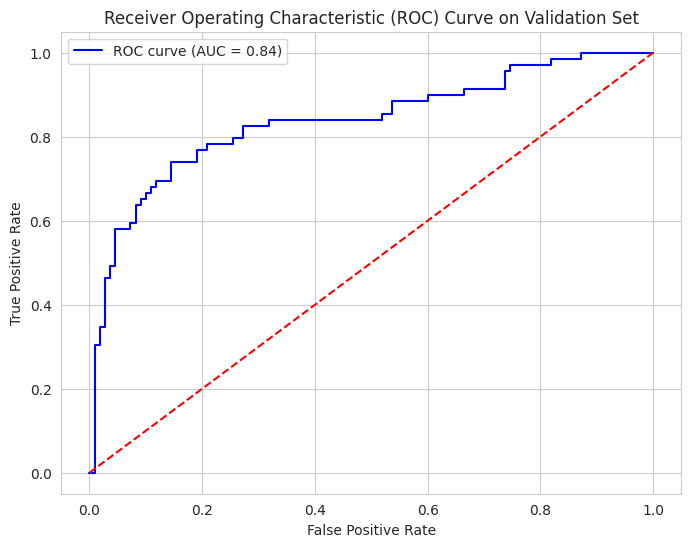

In [35]:
print("\n--- Re-evaluating Model Performance with a Train-Validation Split ---")

# Redefine features (X) and target (y) from the original processed train_df
# X and y were already defined correctly in step 3

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Re-initialize and train the Logistic Regression model on the new training split
model_val = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
model_val.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = model_val.predict(X_val)
y_val_proba = model_val.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Visualize the ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend()
plt.show()

## 5. Interpretation
a. Interpret the coefficients of the logistic regression model.
b. Discuss the significance of features in predicting the target variable (survival probability in this case).

In [ ]:
import pandas as pd

# Get feature names from the X_train DataFrame
feature_names = X_train.columns

# Get the coefficients from the trained model
coefficients = model_val.coef_[0]

# Create a DataFrame to display feature names and their coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to see most influential features
coef_df['Absolute_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Model Coefficients and their Significance:")
display(coef_df)

print("\nInterpretation:")
print("- Positive coefficients indicate that as the feature value increases, the log-odds of survival increase (higher probability of survival).")
print("- Negative coefficients indicate that as the feature value increases, the log-odds of survival decrease (lower probability of survival).")
print("- The magnitude of the coefficient indicates the strength of the influence.")
print("\nBased on the coefficients:")
print(f"- {coef_df.iloc[0]['Feature']} is the most influential feature. A positive coefficient implies a higher probability of survival, while a negative coefficient implies a lower probability of survival.")

## 6. Deployment with Streamlit

In [36]:
import joblib

# Save the trained model
joblib.dump(model_val, 'logistic_regression_model.pkl')
print("Trained model saved as 'logistic_regression_model.pkl'")

# Also save the feature names to ensure consistent input for the Streamlit app
joblib.dump(X.columns.tolist(), 'model_features.pkl')
print("Feature names saved as 'model_features.pkl'")

Trained model saved as 'logistic_regression_model.pkl'
Feature names saved as 'model_features.pkl'


```python
# streamlit_app.py

import streamlit as st
import pandas as pd
import joblib

# Load the trained model and feature names
model = joblib.load('logistic_regression_model.pkl')
model_features = joblib.load('model_features.pkl')

st.title('Titanic Survival Prediction')
st.write('Enter passenger details to predict survival probability.')

# Create input widgets for each feature
pclass = st.selectbox('Pclass (Passenger Class)', [1, 2, 3])
sex = st.selectbox('Sex', ['male', 'female'])
age = st.slider('Age', 0, 80, 28) # Default to median age
sibsp = st.slider('SibSp (Number of Siblings/Spouses Aboard)', 0, 8, 0)
parch = st.slider('Parch (Number of Parents/Children Aboard)', 0, 6, 0)
fare = st.number_input('Fare', min_value=0.0, value=14.45) # Default to median fare
embarked = st.selectbox('Embarked (Port of Embarkation)', ['S', 'C', 'Q']) # Default to mode

# Map categorical inputs to numerical for prediction
sex_mapped = 1 if sex == 'male' else 0
embarked_Q = 1 if embarked == 'Q' else 0
embarked_S = 1 if embarked == 'S' else 0

# Create a DataFrame for the input features
input_data = pd.DataFrame([[pclass, sex_mapped, age, sibsp, parch, fare, embarked_Q, embarked_S]],
                            columns=model_features)

# Ensure column order matches the training data
input_data = input_data[model_features]

if st.button('Predict Survival'):
    prediction = model.predict(input_data)
    prediction_proba = model.predict_proba(input_data)[:, 1]

    if prediction[0] == 1:
        st.success(f'The passenger is predicted to Survive with a probability of {prediction_proba[0]:.2f}')
    else:
        st.error(f'The passenger is predicted to Not Survive with a probability of {prediction_proba[0]:.2f}')
```

## Interview Questions

### Q1: What is the difference between precision and recall?

In binary classification, **Precision** and **Recall** are two crucial metrics derived from the confusion matrix that help evaluate the performance of a model, especially when class distributions are imbalanced. They focus on the positive class predictions.

Let's define the terms from the confusion matrix first:
-   **True Positives (TP)**: Correctly predicted positive instances.
-   **False Positives (FP)**: Incorrectly predicted positive instances (Type I error).
-   **False Negatives (FN)**: Incorrectly predicted negative instances (Type II error).
-   **True Negatives (TN)**: Correctly predicted negative instances.

### Precision (Positive Predictive Value)

**Definition:** Precision measures the proportion of correctly predicted positive observations among all observations predicted as positive. It answers the question: "Of all the instances I predicted as positive, how many were actually positive?"

**Formula:**
`Precision = TP / (TP + FP)`

**When it's important:** Precision is critical when the cost of False Positives is high. For example:
-   **Spam Detection:** A high-precision spam filter ensures that legitimate emails are not incorrectly marked as spam (low FP), which is more important than catching every single spam email.
-   **Medical Diagnosis (for severe conditions):** If a positive prediction means an invasive and risky treatment, we want to be very precise to avoid unnecessary procedures on healthy patients.

### Recall (Sensitivity or True Positive Rate)

**Definition:** Recall measures the proportion of actual positive observations that are correctly identified by the model. It answers the question: "Of all the instances that were actually positive, how many did I correctly predict as positive?"

**Formula:**
`Recall = TP / (TP + FN)`

**When it's important:** Recall is critical when the cost of False Negatives is high. For example:
-   **Fraud Detection:** It's more important to identify as many fraudulent transactions as possible (high TP, low FN), even if some legitimate transactions are flagged for review (some FP).
-   **Medical Diagnosis (for life-threatening diseases):** Missing a diagnosis (FN) can have severe consequences, so a high recall is prioritized to identify as many sick patients as possible.

### Key Difference and Trade-off:
-   **Precision focuses on the accuracy of positive predictions.** It aims to minimize False Positives.
-   **Recall focuses on finding all positive instances.** It aims to minimize False Negatives.

There is often a **trade-off** between precision and recall. Improving one typically comes at the expense of the other. For instance, if you make your model very strict about predicting a positive class (e.g., to reduce FPs), you might miss some actual positive instances (increasing FNs and lowering recall).

### Q2: What is cross-validation, and why is it important in binary classification?

### Cross-Validation

**Definition:** Cross-validation is a resampling procedure used to evaluate machine learning models on a limited data sample. The goal is to estimate how accurately a predictive model will perform in practice on unseen data. It helps in assessing the generalization ability of the model and guarding against overfitting.

Instead of just splitting the data into a single train and test set, cross-validation involves multiple splits and training/evaluation cycles.

### How it works (e.g., k-Fold Cross-Validation):
1.  The entire dataset is randomly partitioned into `k` equally sized (or nearly equally sized) non-overlapping subsets, called "folds."
2.  The model is trained `k` times.
3.  In each iteration `i` (from 1 to `k`):
    *   The `i`-th fold is used as the test set (or validation set).
    *   The remaining `k-1` folds are combined to form the training set.
    *   The model is trained on the training set and evaluated on the test set.
4.  The performance metric (e.g., accuracy, precision, recall, F1-score) from each of the `k` evaluation steps is recorded.
5.  Finally, the `k` performance results are averaged to produce a single, more robust estimate of the model's performance.

### Why it is Important in Binary Classification (and ML in general):

1.  **Robust Performance Estimate:** A single train-test split can be highly dependent on how the data was randomly split. If the split results in a training set that is not representative or a test set that is particularly easy or hard, the performance estimate will be biased. Cross-validation averages results over multiple splits, providing a more reliable and less biased estimate of the model's true performance on unseen data.

2.  **Overfitting Detection and Mitigation:** By evaluating the model on different subsets of the data, cross-validation helps detect if the model is overfitting to the training data. If a model performs very well on the training folds but poorly on the test folds across multiple iterations, it's a strong indicator of overfitting. This allows for hyperparameter tuning or model adjustments to improve generalization.

3.  **Efficient Use of Data:** When working with smaller datasets, reserving a large portion for a single test set can significantly reduce the amount of data available for training, leading to a less robust model. Cross-validation allows every data point to be used for both training and testing across different folds, maximizing the utility of the available data.

4.  **Hyperparameter Tuning:** Cross-validation is essential for selecting the best hyperparameters for a model. Techniques like GridSearchCV or RandomizedSearchCV use cross-validation internally to evaluate different hyperparameter combinations and choose the one that yields the best average performance.

5.  **Handles Class Imbalance (with Stratified K-Fold):** In binary classification, especially when one class is significantly less frequent than the other (class imbalance), a simple random split might lead to folds where one class is completely missing or underrepresented. **Stratified k-Fold Cross-Validation** addresses this by ensuring that each fold has approximately the same proportion of observations for each class as the original dataset. This is crucial for obtaining reliable performance estimates for both classes, particularly for the minority class, which is often the class of interest (e.g., fraud, disease).